## BEE2041: Data Science in Economics

#### University of Exeter Business School

#### Empirical Project

#### Student Number: 730056011

#### Module Convenor: Damian Clarke

#### Due Date + Extension: 1st May 15:00 (GMT)

#### Code Document
---

#### Jupyter Notebook Overview
This notebook contains all the necessary code and steps to reproduce the analysis. It's designed for transparency and reproducibility, so you can see exactly how the data was loaded, cleaned, processed, and analyzed.

You can follow along with the code, but the blog post (linked below) provides a more structured, user-friendly version of the analysis for general readers. The blog post focuses on the key insights derived from the data.

https://8-7publication2015-2016.blogspot.com/2025/04/what-climbers-really-love-analysing.html


## Importing and Cleaning of Data

The data for this analysis is loaded from CSV files containing information on bouldering routes from three regions: Joshua Tree, Joe's Valley, and Hueco Tanks.

Key steps:

- Import necessary libraries.

- Load CSV files into dataframes.

- Add a "Location" column to track which region each route belongs to.

- Drop irrelevant columns (e.g., URLs, route types) to focus on useful information.

- Clean the "Rating" column to extract numeric grades (e.g., "V4", "V5").

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import re
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Configure
sns.set(style = "whitegrid")

In [4]:
# Load and check CSV's
df_joshua = pd.read_csv("/Users/sam/Desktop/climbing_project/project_files/data/joshua_tree.csv")
df_joe = pd.read_csv("/Users/sam/Desktop/climbing_project/project_files/data/joes_valley.csv")
df_hueco = pd.read_csv("/Users/sam/Desktop/climbing_project/project_files/data/hueco_tanks.csv")

In [5]:
df_joshua.head(10)

,Route,Location,URL,Avg Stars,Num Ratings,Your Stars,Route Type,Rating,Pitches,Length,Area Latitude,Area Longitude
0,White Rastafarian,White Rastafarian Boulder > Outback Bouldering...,https://www.mountainproject.com/route/10572259...,3.9,291,-1,Boulder,V2 R,1,20.0,34.02066,-116.16208
1,Slashface,Slash Boulder > Western Belt > Geology Tour Ro...,https://www.mountainproject.com/route/10572275...,3.9,130,-1,Boulder,V3 R,1,25.0,33.95344,-116.08706
2,Pigpen,Pigpen Boulder > Manx Boulders Circuit > Manx/...,https://www.mountainproject.com/route/10572299...,3.9,229,-1,Boulder,V4,1,10.0,34.01530,-116.15811
3,JBMFP,JBMF Boulder > JBMF Boulders > Roadside Rocks ...,https://www.mountainproject.com/route/10572546...,3.9,239,-1,Boulder,V5,1,16.0,34.01520,-116.16631
4,Gunsmoke,Gunsmoke Wall > Gunsmoke Area > Barker Dam Bou...,https://www.mountainproject.com/route/10572235...,3.7,527,-1,Boulder,V3,1,80.0,34.02858,-116.14508
5,Stem Gem,Stem Gem Boulder > HVCG West > HVCG Bouldering...,https://www.mountainproject.com/route/10572260...,3.8,268,-1,Boulder,V4,1,20.0,34.01716,-116.16368
6,Fry Problem,Fry Boulder > Fry Boulders > Stonehenge and Fr...,https://www.mountainproject.com/route/10603937...,3.7,192,-1,Boulder,V2,1,15.0,33.98831,-116.15795
7,False Up 20,False Up 20 Boulder > JBMF Boulders > Roadside...,https://www.mountainproject.com/route/10572546...,3.6,238,-1,Boulder,V0-,1,20.0,34.01513,-116.16605
8,Saturday Night Live,Saturday Night Live Boulder > Real Hidden Vall...,https://www.mountainproject.com/route/10572351...,3.6,186,-1,Boulder,V4,1,13.0,34.01167,-116.16855
9,The Chube,Chube Boulder > Gunsmoke Area > Barker Dam Bou...,https://www.mountainproject.com/route/10572444...,3.4,400,-1,Boulder,V2,1,15.0,34.02838,-116.14524


In [6]:
# Add location column for each
df_joshua["Location"] = "Joshua Tree"
df_joe["Location"] = "Joe's Valley"
df_hueco["Location"] = "Hueco Tanks"

In [7]:
# Combine into one dataframe
df_all = pd.concat([df_joshua, df_joe, df_hueco], ignore_index = True)

In [8]:
# Get rid of redundant columns
columns_to_drop = ['URL', 'Your Stars', 'Route Type', 'Length', 'Pitches',]
df_all = df_all.drop(columns = columns_to_drop)

In [9]:
# Quick View
df_all

,Route,Location,Avg Stars,Num Ratings,Rating,Area Latitude,Area Longitude
0,White Rastafarian,Joshua Tree,3.9,291,V2 R,34.02066,-116.16208
1,Slashface,Joshua Tree,3.9,130,V3 R,33.95344,-116.08706
2,Pigpen,Joshua Tree,3.9,229,V4,34.01530,-116.15811
3,JBMFP,Joshua Tree,3.9,239,V5,34.01520,-116.16631
4,Gunsmoke,Joshua Tree,3.7,527,V3,34.02858,-116.14508
...,...,...,...,...,...,...,...
2485,V0 Runnel,Hueco Tanks,2.0,1,V0,31.91559,-106.04608
2486,V1 Vert,Hueco Tanks,2.0,2,V1,31.91559,-106.04608
2487,V2 Huecos,Hueco Tanks,2.5,2,V2,31.91559,-106.04608
2488,Pink Moon,Hueco Tanks,3.0,2,V5,31.91563,-106.04213


In [10]:
# Clean up the grades into workable integers
def clean_v_grade(grade_str):
    match = re.match(r"V(\d+)", str(grade_str))
    return int(match.group(1)) if match else None

# Usage on a DataFrame column
df_all['Numeric_Grade'] = df_all['Rating'].apply(clean_v_grade)
df_all = df_all.dropna(subset = ["Numeric_Grade", "Avg Stars"])
df_all

,Route,Location,Avg Stars,Num Ratings,Rating,Area Latitude,Area Longitude,Numeric_Grade
0,White Rastafarian,Joshua Tree,3.9,291,V2 R,34.02066,-116.16208,2.0
1,Slashface,Joshua Tree,3.9,130,V3 R,33.95344,-116.08706,3.0
2,Pigpen,Joshua Tree,3.9,229,V4,34.01530,-116.15811,4.0
3,JBMFP,Joshua Tree,3.9,239,V5,34.01520,-116.16631,5.0
4,Gunsmoke,Joshua Tree,3.7,527,V3,34.02858,-116.14508,3.0
...,...,...,...,...,...,...,...,...
2485,V0 Runnel,Hueco Tanks,2.0,1,V0,31.91559,-106.04608,0.0
2486,V1 Vert,Hueco Tanks,2.0,2,V1,31.91559,-106.04608,1.0
2487,V2 Huecos,Hueco Tanks,2.5,2,V2,31.91559,-106.04608,2.0
2488,Pink Moon,Hueco Tanks,3.0,2,V5,31.91563,-106.04213,5.0


In [11]:
# View the info
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2315 entries, 0 to 2489
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Route           2315 non-null   object 
 1   Location        2315 non-null   object 
 2   Avg Stars       2315 non-null   float64
 3   Num Ratings     2315 non-null   int64  
 4   Rating          2315 non-null   object 
 5   Area Latitude   2315 non-null   float64
 6   Area Longitude  2315 non-null   float64
 7   Numeric_Grade   2315 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 162.8+ KB


In [12]:
# Create a filtered data set that include only routes with Avg Stars >= 0 -- Used for ratings related graphs
df_filtered = df_all[df_all["Avg Stars"] >= 0]
df_filtered.head(10)

,Route,Location,Avg Stars,Num Ratings,Rating,Area Latitude,Area Longitude,Numeric_Grade
0,White Rastafarian,Joshua Tree,3.9,291,V2 R,34.02066,-116.16208,2.0
1,Slashface,Joshua Tree,3.9,130,V3 R,33.95344,-116.08706,3.0
2,Pigpen,Joshua Tree,3.9,229,V4,34.01530,-116.15811,4.0
3,JBMFP,Joshua Tree,3.9,239,V5,34.01520,-116.16631,5.0
4,Gunsmoke,Joshua Tree,3.7,527,V3,34.02858,-116.14508,3.0
5,Stem Gem,Joshua Tree,3.8,268,V4,34.01716,-116.16368,4.0
6,Fry Problem,Joshua Tree,3.7,192,V2,33.98831,-116.15795,2.0
7,False Up 20,Joshua Tree,3.6,238,V0-,34.01513,-116.16605,0.0
8,Saturday Night Live,Joshua Tree,3.6,186,V4,34.01167,-116.16855,4.0
9,The Chube,Joshua Tree,3.4,400,V2,34.02838,-116.14524,2.0


## Creation of Graphs for First Section - Comparing Difficulty Distributions Across Regions

To understand the distribution of difficulty levels across regions, we:

- Plot a histogram of grades (V0, V1, etc.) for each region.

- Create a bar plot to visualize the total number of ratings for each grade.



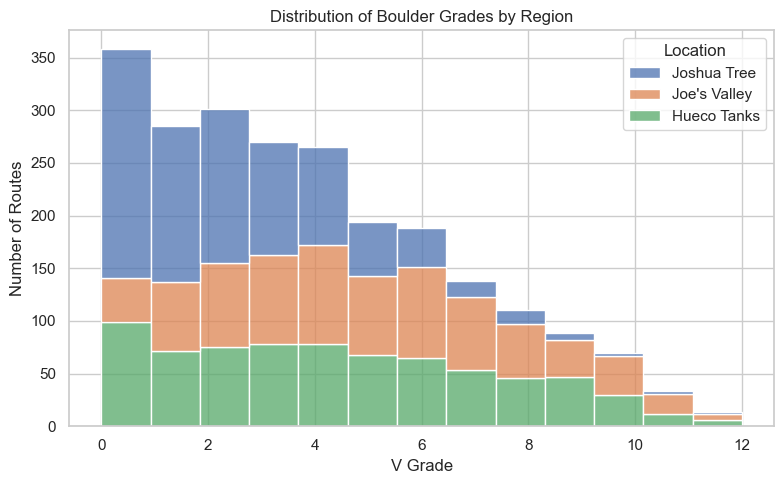

In [13]:
# Plot: Histogram of grades
plt.figure(figsize = (8, 5))
sns.histplot(df_all, x = "Numeric_Grade", hue = "Location", multiple = "stack", bins = 13)
plt.title("Distribution of Boulder Grades by Region")
plt.xlabel("V Grade")
plt.ylabel("Number of Routes")
plt.tight_layout()
plt.show()

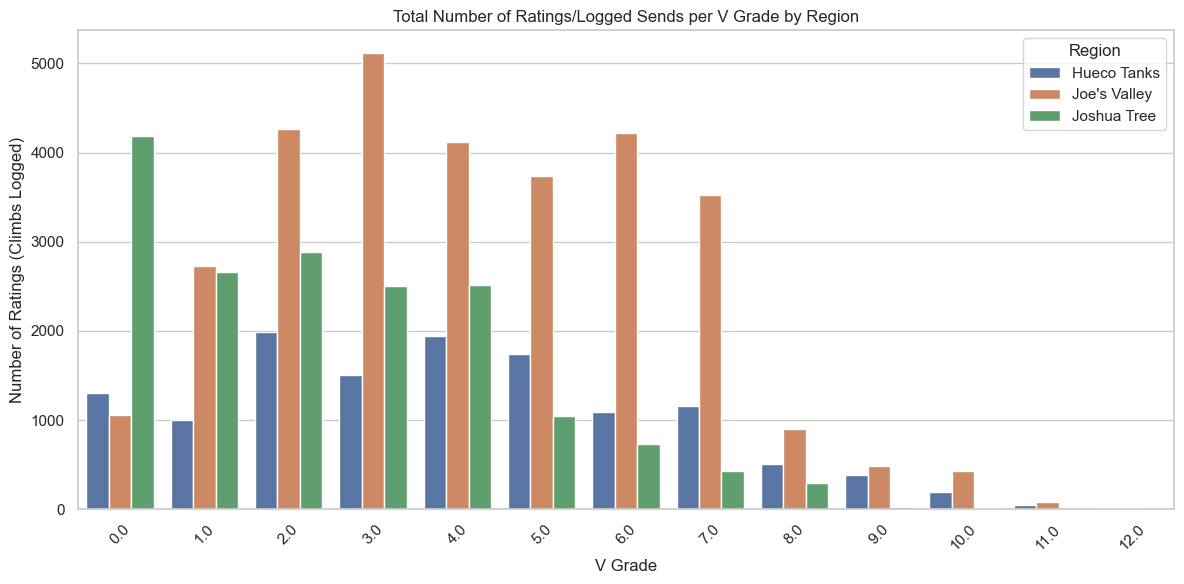

In [14]:
# Group by grade and location, summing number of ratings
ratings_per_grade = df_all.groupby(['Numeric_Grade', 'Location'])['Num Ratings'].sum().reset_index()

# Set up the plot
plt.figure(figsize = (12, 6))
sns.barplot(
    data = ratings_per_grade,
    x = 'Numeric_Grade',
    y = 'Num Ratings',
    hue = 'Location'
)

plt.title("Total Number of Ratings/Logged Sends per V Grade by Region")
plt.xlabel("V Grade")
plt.ylabel("Number of Ratings (Climbs Logged)")
plt.xticks(rotation = 45)
plt.legend(title = "Region")
plt.tight_layout()
plt.show()

## Creation of Graphs for Section 2: Do Climbers Prefer Easier Routes?

We investigate if easier routes tend to receive higher ratings by:

- Plotting a scatter plot to show the relationship between route grade and average rating.

- Adding a smoothed regression line to highlight trends.

- Using a box plot to compare ratings across different grades.



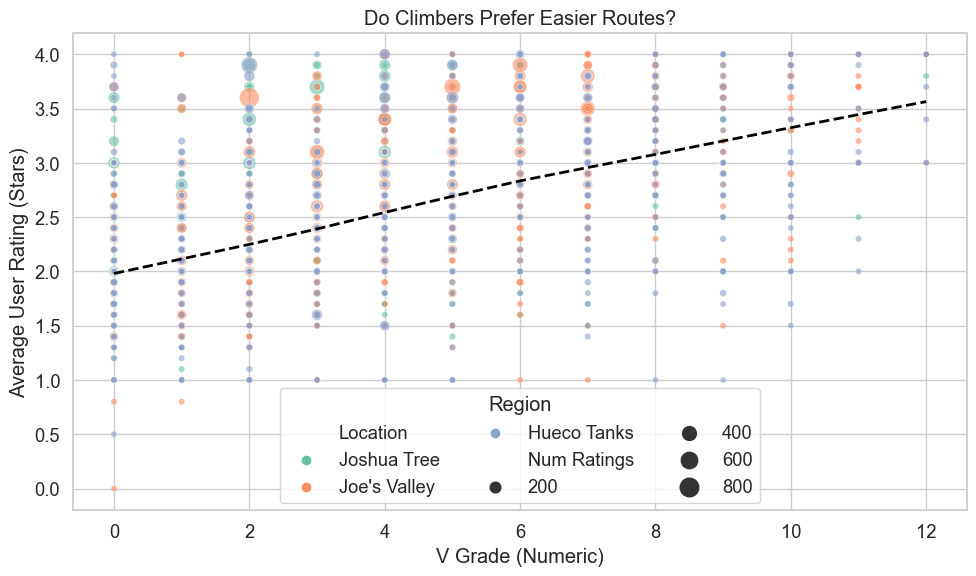

In [15]:
# Set a consistent plot style
sns.set(style = "whitegrid", font_scale = 1.2)

# Create scatterplot: difficulty (Numeric_Grade) vs average user rating
plt.figure(figsize = (10, 6))
scatter = sns.scatterplot(
    data = df_filtered,
    x = "Numeric_Grade",
    y = "Avg Stars",
    hue = "Location",
    size = "Num Ratings",  # Size based on number of ratings
    sizes = (20, 200),     # Adjust the range of point sizes as needed
    palette = "Set2",
    alpha = 0.6          # Slight transparency to help with overlapping
)

# Add smoothing trend line
sns.regplot(
    data = df_filtered,
    x = "Numeric_Grade",
    y = "Avg Stars",
    scatter = False,
    lowess = True,
    color = "black",
    line_kws = {'linewidth': 2, 'linestyle': 'dashed'}
)

plt.title("Do Climbers Prefer Easier Routes?")
plt.xlabel("V Grade (Numeric)")
plt.ylabel("Average User Rating (Stars)")
plt.legend(title = "Region", loc = 'lower center', bbox_to_anchor = (0.5, -0.005), ncol = 3) # changed the location of the legend
plt.tight_layout()
plt.show()



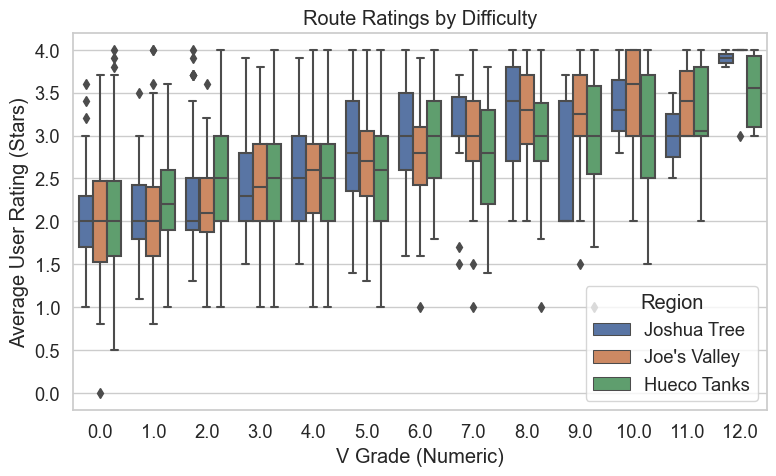

In [16]:
# Plot: Route Ratings by Difficulty
plt.figure(figsize = (8, 5))
sns.boxplot(data = df_filtered, x = "Numeric_Grade", y = "Avg Stars", hue = "Location")

plt.title("Route Ratings by Difficulty")
plt.xlabel("V Grade (Numeric)")
plt.ylabel("Average User Rating (Stars)")
plt.legend(title = "Region")
plt.tight_layout()
plt.show()

## Creating a Predictive Model

We build a linear regression model to predict route ratings based on difficulty, number of ratings, and location. The model includes:

- A transformation of the "Num Ratings" feature (log-scale) to reduce skew.

- One-hot encoding for the "Location" feature.

- A split into training and testing data for model evaluation.

R² Score: 0.3049798367708493
RMSE: 0.6379321467402654


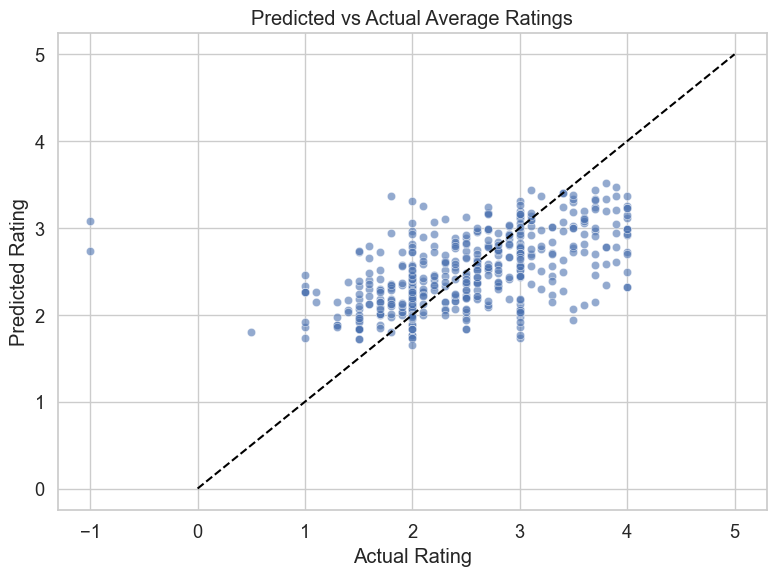

                 Feature  Coefficient
1        Log_Num_Ratings     0.165496
0          Numeric_Grade     0.132995
3   Location_Joshua Tree     0.035083
2  Location_Joe's Valley    -0.076674


In [17]:
# Select features and target
df_model = df_all.copy()
df_model = df_model[df_model["Avg Stars"].notnull()]  # Drop missing ratings

# Log-transform number of ratings to reduce skew
df_model["Log_Num_Ratings"] = np.log1p(df_model["Num Ratings"])

# One-hot encode 'Location'
df_encoded = pd.get_dummies(df_model[["Numeric_Grade", "Log_Num_Ratings", "Location"]], drop_first=True)

# Define X and y
X = df_encoded
y = df_model["Avg Stars"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Plot predicted vs actual
plt.figure(figsize = (8,6))
sns.scatterplot(x = y_test, y = y_pred, alpha = 0.6)
plt.plot([0, 5], [0, 5], linestyle = "--", color = "black")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Predicted vs Actual Average Ratings")
plt.tight_layout()
plt.show()

# Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by = "Coefficient", ascending=False)

print(coef_df)

## Getting Statistics for Top Rated Climbs in Joe’s Valley by Difficulty

We filter for popular routes (at least 10 ratings) in Joe's Valley and sort them by their average rating within three difficulty levels: beginner (V0–V4), intermediate (V5–V8), and advanced (V9+).



In [18]:
# Filter the entire dataset for routes with at least 10 ratings
df_rating = df_all[df_all["Num Ratings"] >= 10]

# Filter data for Joe's Valley from the already filtered dataset
joes_valley_routes = df_rating[df_rating["Location"] == "Joe's Valley"]

# Beginner: V0 to V4
beginner_routes = joes_valley_routes[(joes_valley_routes['Numeric_Grade'] >= 0) & (joes_valley_routes['Numeric_Grade'] <= 4)]
top_beginner = beginner_routes.sort_values("Avg Stars", ascending=False).head(10)
print("\nTop Rated Beginner Routes (V0–V4):\n", top_beginner[["Route", "Avg Stars", "Num Ratings", "Rating"]])

# Intermediate: V5 to V8
intermediate_routes = joes_valley_routes[(joes_valley_routes['Numeric_Grade'] >= 5) & (joes_valley_routes['Numeric_Grade'] <= 8)]
top_intermediate = intermediate_routes.sort_values("Avg Stars", ascending=False).head(10)
print("\nTop Rated Intermediate Routes (V5–V8):\n", top_intermediate[["Route", "Avg Stars", "Num Ratings", "Rating"]])

# Advanced: V9 and above
advanced_routes = joes_valley_routes[joes_valley_routes['Numeric_Grade'] >= 9]
top_advanced = advanced_routes.sort_values("Avg Stars", ascending=False).head(10)
print("\nTop Rated Advanced Routes (V9+):\n", top_advanced[["Route", "Avg Stars", "Num Ratings", "Rating"]])


Top Rated Beginner Routes (V0–V4):
                      Route  Avg Stars  Num Ratings Rating
1337            Kobra Khan        4.0          202     V4
1419          Michelangelo        3.8          160   V3 R
1477                 Speed        3.7           48   V3 R
1462              Thriller        3.7          108   V0 R
1196            The Angler        3.6          902     V2
1341            The Kraken        3.6           37   V4 R
1231  America's Playground        3.6          128   V1-2
1681           Candy Paint        3.6           37     V3
1365           Wax or Wane        3.5           34     V4
1151          Sandy Cheeks        3.5           22     V4

Top Rated Intermediate Routes (V5–V8):
                            Route  Avg Stars  Num Ratings Rating
1265              The Wind Below        4.0           78     V7
1615               Thor's Hammer        3.9           76     V7
1696                     The Flu        3.9          120   V7-8
1239                  Lumber